In [1]:
import torch
from clean_lib.checkpoints import CheckpointManager
from clean_lib.sae import SparseAEs, Normalizer
from clean_lib.processors.processor import Processor
from clean_lib.processors.H import H
from clean_lib.processors.D import D
from clean_lib.processors.R import R
from clean_lib.processors.Hc import Hc
from clean_lib.processors.M import M
from clean_lib.analyzer import Analyzer
from clean_lib.visualize import visualize_concept_on_class


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
N = 1
backbone_dir = "./PACS_ResNet_Sketch_Test_Only/ERM_ResNet_T3"

backbone_manager = CheckpointManager(directory=backbone_dir)
ckpts_oracle, _ = backbone_manager.get_top_k_checkpoints(envs=[0, 1, 2, 3], k = N)
ckpts_nonoracle, _ = backbone_manager.get_top_k_checkpoints(envs=[0, 1, 2], k = N)

print(f"Top - {N} checkpoints Oracle: {ckpts_oracle}")
print(f"Top - {N} checkpoints Non - Oracle: {ckpts_nonoracle}")

backbone_manager.load_checkpoints(set(ckpts_oracle).union(set(ckpts_nonoracle)))

Top - 1 checkpoints Oracle: [2100]
Top - 1 checkpoints Non - Oracle: [3300]


In [3]:
sae_manager = SparseAEs(
    feature_dim=2048, 
    topk=16, 
    nb_concepts=2048*8, 
    rearrange_string="n c w h -> (n w h) c", 
    checkpointManager=backbone_manager, 
    train_envs=[0, 1, 2],
    w=7
)

sae_manager.load_checkpoint("./SAEs/normalization_testing/USAE_ERM_Multi_test_3300_2100.pt")

In [4]:
ckpt = 3300

processor = Processor(
    sae_manager=sae_manager,
    ckpt=ckpt,
    process_domains=[0, 1, 2],
    file_path=f"./processed/NEW_ERM_ResNet_{ckpt}_T3.json",
)

Configured for PACS dataset.


## Processors

In [5]:
h = H.from_processor(processor)
h.process()

Configured for PACS dataset.


100%|██████████| 20/20 [00:02<00:00,  7.02it/s]


KeyboardInterrupt: 

In [5]:
d = D.from_processor(processor)
d.process()

Configured for PACS dataset.


Calculating Concept Discrimination: 100%|██████████| 75/75 [03:10<00:00,  2.54s/it]


In [5]:
r = R.from_processor(processor)
r.process()

Configured for PACS dataset.


R scores [photo]: 100%|██████████| 20/20 [00:46<00:00,  2.35s/it]


tensor([ 1.3568e-05, -3.7515e-05,  2.6822e-07], device='cuda:0')
tensor([ 1.7030e-08,  6.1045e-07, -8.5149e-09], device='cuda:0')
tensor([-3.9736e-08, -1.5870e-06,  2.3842e-08], device='cuda:0')
tensor([ 3.3504e-07, -1.1838e-05,  2.1776e-06], device='cuda:0')
tensor([ 2.8043e-07, -1.2547e-07, -2.2151e-07], device='cuda:0')
tensor([-5.5020e-04, -3.0547e-04,  1.8746e-05], device='cuda:0')
tensor([ 1.1196e-05, -4.4158e-06,  5.3800e-06], device='cuda:0')
tensor([ 6.1371e-05, -1.5366e-05,  1.3045e-05], device='cuda:0')
tensor([-7.2826e-06,  1.2673e-05, -1.1524e-06], device='cuda:0')
tensor([-1.1921e-07,  3.9736e-08,  0.0000e+00], device='cuda:0')
tensor([-1.2483e-03, -5.9469e-04,  6.2585e-06], device='cuda:0')
tensor([ 2.8874e-04, -2.1320e-03,  6.1691e-06], device='cuda:0')
tensor([ 2.0700e-08,  2.3038e-08, -3.3980e-08], device='cuda:0')
tensor([-1.1921e-07,  1.1921e-07,  0.0000e+00], device='cuda:0')
tensor([ 2.9649e-08,  1.4204e-06, -5.0970e-07], device='cuda:0')
tensor([-4.1611e-08,  5.1

In [ ]:
hc = Hc.from_processor(processor)
hc.process()

In [ ]:
m = M.from_processor(processor)
m.process()

## Analysis

Masked Accuracy Evaluator

In [6]:
import torch
import torch.nn.functional as F
from einops import rearrange
from tqdm import tqdm
from collections import defaultdict
import numpy as np

from clean_lib.data import Load_PACS
from clean_lib.utils import extract_features
from timm.layers import SelectAdaptivePool2d



class MaskedAccuracyEvaluator:
    def __init__(self, processor):

        self.backbone = processor.backbone
        self.sae_manager = processor.sae_manager
        self.sae = processor.sae
        self.domains = processor.domains
        self.classes = processor.classes
        self.class_names = processor.class_names

    # ------------------------------------------------------------------
    # Public API
    # ------------------------------------------------------------------

    def calculate_masked_accuracy(self, concept_mask: torch.Tensor):
        assert concept_mask.dtype == torch.bool, "concept_mask must be a boolean tensor."

        if concept_mask.ndim == 1:
            assert concept_mask.shape[0] == self.sae_manager.nb_concepts, (
                f"1D concept_mask length {concept_mask.shape[0]} does not match "
                f"nb_concepts {self.sae_manager.nb_concepts}."
            )
        elif concept_mask.ndim == 2:
            assert concept_mask.shape == (self.classes, self.sae_manager.nb_concepts), (
                f"2D concept_mask shape {tuple(concept_mask.shape)} does not match "
                f"(classes={self.classes}, nb_concepts={self.sae_manager.nb_concepts})."
            )
        else:
            raise ValueError(
                f"concept_mask must be 1D (nb_concepts,) or 2D (classes, nb_concepts), "
                f"got shape {tuple(concept_mask.shape)}."
            )

        per_domain_stats = self._run_inference(concept_mask)
        report = self._build_report(per_domain_stats)
        self._print_report(report)
        return report

    # ------------------------------------------------------------------
    # Inference
    # ------------------------------------------------------------------

    def _run_inference(self, concept_mask: torch.Tensor):
        pool = SelectAdaptivePool2d(pool_type="avg", flatten=True)
        is_resnet = self.backbone.featurizer.__class__.__name__ == "ResNet"
        is_2d_mask = concept_mask.ndim == 2

        self.sae.to(device)
        self.backbone.to(device)
        self.backbone.eval()
        self.sae.eval()

        concept_mask = concept_mask.to(device)
        per_domain_stats = {}

        for domain_idx, domain in enumerate(self.domains):
            domain_name = self.domains[domain_idx]
            correct = torch.zeros(self.classes, device=device)
            total = torch.zeros(self.classes, device=device)

            dataloader, _ = Load_PACS(domains=[domain], batch_size=64)

            for x, y in tqdm(dataloader, desc=f"Evaluating domain: {domain_name}"):
                x, y = x.to(device), y.to(device)
                n = x.size(0)

                with torch.no_grad():
                    # ---- Feature extraction ----
                    z_raw = extract_features(self.backbone, x)
                    z_norm = self.sae.normalizer(z_raw)
                    _, _, h, w = z_norm.shape

                    z_flat = rearrange(z_norm, "n c h w -> (n h w) c")
                    _, z_sae = self.sae.encode(z_flat)

                    # ---- Apply concept mask ----
                    if is_2d_mask:
                        # concept_mask[y] → (n, nb_concepts): each sample gets
                        # the mask row for its own class.
                        # Repeat each row h*w times to align with the flattened
                        # spatial tokens: (n, nb_concepts) → (n*h*w, nb_concepts).
                        per_sample_mask = concept_mask[y]                      # (n, nb_concepts)
                        per_token_mask  = per_sample_mask.repeat_interleave(   # (n*h*w, nb_concepts)
                            h * w, dim=0
                        )
                        z_sae = z_sae * (~per_token_mask).float()
                    else:
                        # 1D: broadcast the same mask over all tokens
                        z_sae[:, concept_mask] = 0.0

                    # ---- Reconstruct and classify ----
                    z_recon_flat = self.sae.decode(z_sae)
                    z_recon = rearrange(
                        z_recon_flat, "(n h w) c -> n c h w", n=n, h=h, w=w
                    )
                    z_recon = self.sae.normalizer.denormalize(z_recon)

                    if is_resnet:
                        logits = self.backbone.classifier(pool(z_recon))
                    else:
                        logits = self.backbone.classifier(z_recon)

                    preds = logits.argmax(dim=1)

                # ---- Accumulate per-class counts ----
                for cls in range(self.classes):
                    cls_mask = y == cls
                    correct[cls] += (preds[cls_mask] == y[cls_mask]).sum()
                    total[cls] += cls_mask.sum()

            per_domain_stats[domain_name] = {"correct": correct, "total": total}

        return per_domain_stats

    
    def _build_report(self, per_domain_stats: dict) -> dict:
        """
        Construct the full accuracy report from raw correct/total counts.

        Report schema
        -------------
        {
          "per_domain": {
            "<domain>": {
              "per_class": { "<class>": float },   # accuracy 0–1
              "macro_avg": float                    # avg over classes
            }
          },
          "per_class_avg_over_domains": {           # macro avg over domains, per class
            "<class>": float
          },
          "per_domain_avg_over_classes": {          # macro avg over classes, per domain
            "<domain>": float  (same as per_domain[domain]["macro_avg"])
          },
          "overall_avg": float                      # scalar: avg over all domains × classes
        }
        """
        report = {
            "per_domain": {},
            "per_class_avg_over_domains": {},
            "per_domain_avg_over_classes": {},
            "overall_avg": 0.0,
        }

        # ---- Per-domain, per-class accuracies ----
        # class_domain_accs[cls_name] collects one accuracy per domain
        class_domain_accs = defaultdict(list)

        for domain_name, stats in per_domain_stats.items():
            correct = stats["correct"]   # shape (classes,)
            total = stats["total"]       # shape (classes,)

            per_class_acc = {}
            for cls_idx, cls_name in enumerate(self.class_names):
                n = total[cls_idx].item()
                acc = (correct[cls_idx] / n).item() if n > 0 else float("nan")
                per_class_acc[cls_name] = acc
                if not np.isnan(acc):
                    class_domain_accs[cls_name].append(acc)

            # Macro average over classes for this domain
            valid = [v for v in per_class_acc.values() if not np.isnan(v)]
            macro = float(np.mean(valid)) if valid else float("nan")

            report["per_domain"][domain_name] = {
                "per_class": per_class_acc,
                "macro_avg": macro,
            }
            report["per_domain_avg_over_classes"][domain_name] = macro

        # ---- Per-class average over domains ----
        for cls_name, accs in class_domain_accs.items():
            report["per_class_avg_over_domains"][cls_name] = (
                float(np.mean(accs)) if accs else float("nan")
            )

        # ---- Overall average ----
        all_domain_macros = [
            v
            for v in report["per_domain_avg_over_classes"].values()
            if not np.isnan(v)
        ]
        report["overall_avg"] = (
            float(np.mean(all_domain_macros)) if all_domain_macros else float("nan")
        )

        return report

    # ------------------------------------------------------------------
    # Pretty Printing
    # ------------------------------------------------------------------

    def _print_report(self, report: dict):
        col_w = 14
        cls_names = self.class_names

        def _pct(v):
            return f"{v * 100:6.2f}%" if not np.isnan(v) else "   N/A "

        header_cols = "".join(f"{c:>{col_w}}" for c in cls_names)
        row_width = 20 + len(cls_names) * col_w + col_w

        print("\n" + "=" * row_width)
        print("  MASKED ACCURACY REPORT")
        print("=" * row_width)

        # Header row
        print(f"{'Domain':<20}" + header_cols + f"{'MacroAvg':>{col_w}}")
        print("-" * row_width)

        # One row per domain
        for domain_name, domain_data in report["per_domain"].items():
            row = f"{domain_name:<20}"
            for cls_name in cls_names:
                acc = domain_data["per_class"].get(cls_name, float("nan"))
                row += f"{_pct(acc):>{col_w}}"
            row += f"{_pct(domain_data['macro_avg']):>{col_w}}"
            print(row)

        print("-" * row_width)

        # Average over domains (per class)
        avg_row = f"{'Avg over domains':<20}"
        for cls_name in cls_names:
            acc = report["per_class_avg_over_domains"].get(cls_name, float("nan"))
            avg_row += f"{_pct(acc):>{col_w}}"
        avg_row += f"{_pct(report['overall_avg']):>{col_w}}"
        print(avg_row)

        print("=" * row_width)
        print(f"  Overall Average Accuracy: {_pct(report['overall_avg'])}")
        print("=" * row_width + "\n")

# Masked Accuracies

In [6]:
analysis = Analyzer(file_path="./processed/NEW_ERM_ResNet_3300_T3.json")

In [8]:
analysis.filter("H_counts", [(30, None)])
clusters = analysis.filter_by_cluster(names=["D"], n_clusters=3)


Per-Class Cluster Analysis (k=3)

  Class 0 (250 concepts)
    Cluster 0: (D: -0.0000) [243 concepts]
    Cluster 1: (D: 0.0509) [1 concepts]
    Cluster 2: (D: -0.0122) [6 concepts]

  Class 1 (183 concepts)
    Cluster 0: (D: 0.0001) [178 concepts]
    Cluster 1: (D: 0.0141) [1 concepts]
    Cluster 2: (D: -0.0018) [4 concepts]

  Class 2 (167 concepts)
    Cluster 0: (D: 0.0000) [162 concepts]
    Cluster 1: (D: 0.0649) [1 concepts]
    Cluster 2: (D: -0.0025) [4 concepts]

  Class 3 (130 concepts)
    Cluster 0: (D: 0.0000) [127 concepts]
    Cluster 1: (D: 0.0057) [2 concepts]
    Cluster 2: (D: 0.0037) [1 concepts]

  Class 4 (214 concepts)
    Cluster 0: (D: 0.0000) [211 concepts]
    Cluster 1: (D: 0.0288) [1 concepts]
    Cluster 2: (D: -0.0051) [2 concepts]

  Class 5 (134 concepts)
    Cluster 0: (D: 0.0000) [129 concepts]
    Cluster 1: (D: 0.0006) [3 concepts]
    Cluster 2: (D: 0.0010) [2 concepts]

  Class 6 (285 concepts)
    Cluster 0: (D: -0.0000) [283 concepts]
    

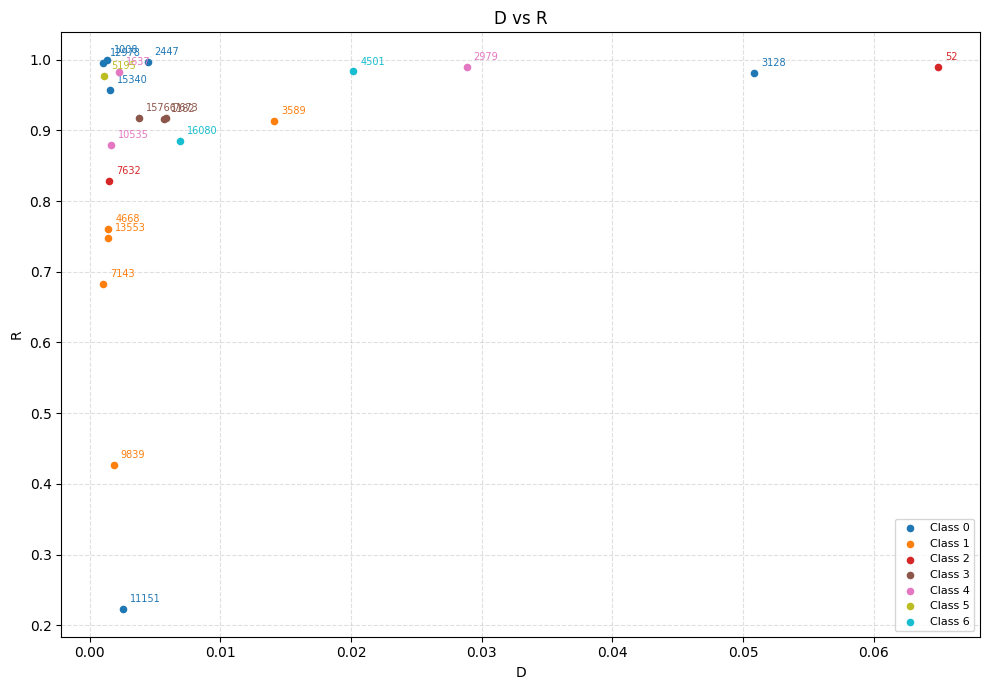

In [8]:
analysis.reset_filters()
analysis.filter("H_counts", [(30, None)])
analysis.filter("D", [(1e-3, None)])
analysis.plot_concepts(x_name="D", y_name="R", view_labels=True)

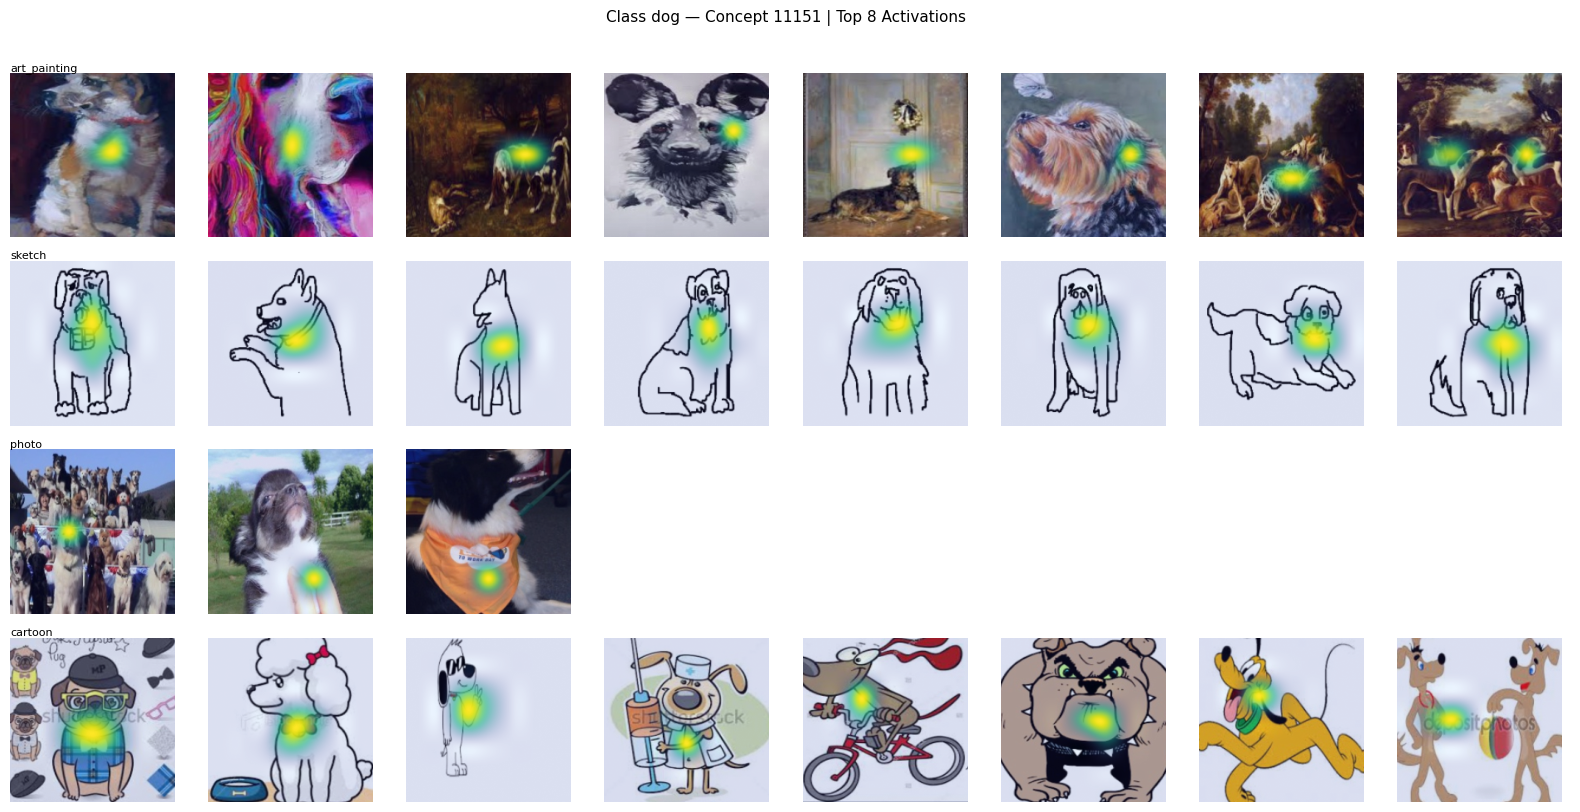

In [14]:
visualize_concept_on_class(
    concept=11151,
    class_idx=0, 
    sae_manager=sae_manager,
    ckpt=3300,
)

### Bucket Level Analysis

Base Check - Remove useless concepts

In [10]:
ckpt = 3300
eval_processor = Processor(
    sae_manager=sae_manager,
    ckpt=ckpt,
    process_domains=[0, 1, 2, 3],
    file_path=f"./processed/eval_ERM_ResNet_{ckpt}_T3.json",
)

evaluator = MaskedAccuracyEvaluator(eval_processor)

Configured for PACS dataset.


In [8]:
analysis.reset_filters()
mask = analysis.get_mask()
evaluator.calculate_masked_accuracy(mask)


analysis.reset_filters()
analysis.filter("H_counts", [(30, None)])
mask = analysis.get_mask()
evaluator.calculate_masked_accuracy(mask)

print("Done")

Evaluating domain: sketch: 100%|██████████| 49/49 [00:08<00:00,  5.78it/s]



  MASKED ACCURACY REPORT
Domain                         dog      elephant       giraffe        guitar         horse         house        person      MacroAvg
------------------------------------------------------------------------------------------------------------------------------------
art_painting                98.98%        97.97%       100.00%       100.00%        99.38%        99.59%        99.70%        99.37%
cartoon                     96.73%        99.45%       100.00%        99.07%        99.20%       100.00%        98.73%        99.03%
photo                       99.31%        99.35%       100.00%       100.00%        99.36%       100.00%       100.00%        99.72%
sketch                      48.55%        95.97%        77.97%        96.86%        81.98%        88.06%        94.66%        83.43%
------------------------------------------------------------------------------------------------------------------------------------
Avg over domains            85.89%        9

Evaluating domain: sketch: 100%|██████████| 49/49 [00:07<00:00,  6.72it/s]


  MASKED ACCURACY REPORT
Domain                         dog      elephant       giraffe        guitar         horse         house        person      MacroAvg
------------------------------------------------------------------------------------------------------------------------------------
art_painting                98.99%        99.01%       100.00%       100.00%        99.38%       100.00%        99.70%        99.58%
cartoon                     98.05%       100.00%       100.00%       100.00%        99.22%       100.00%        99.06%        99.47%
photo                       99.31%        99.35%       100.00%       100.00%        99.36%       100.00%       100.00%        99.72%
sketch                      51.13%        98.16%        83.05%        99.58%        85.19%        91.04%        95.42%        86.23%
------------------------------------------------------------------------------------------------------------------------------------
Avg over domains            86.87%        9

## 

What if we mask High, R, D+ and H

In [9]:
analysis.reset_filters()
analysis.filter("H_counts", [(30, None)])
analysis.filter("D", [(None, 1e-3)])
analysis.filter("H", [(0.0, 0.7)])
analysis.filter("R", [(0.0, 0.7)])
mask = analysis.get_mask()
evaluator.calculate_masked_accuracy(mask)

print("Done")

Evaluating domain: sketch: 100%|██████████| 49/49 [00:07<00:00,  6.85it/s]


  MASKED ACCURACY REPORT
Domain                         dog      elephant       giraffe        guitar         horse         house        person      MacroAvg
------------------------------------------------------------------------------------------------------------------------------------
art_painting                 1.32%         0.00%         0.00%         0.00%         0.00%         0.00%        99.39%        14.39%
cartoon                     84.92%        71.27%         0.00%         0.00%         0.00%         0.00%        98.74%        36.42%
photo                        1.35%         0.00%         0.00%         0.00%         0.00%         0.00%       100.00%        14.48%
sketch                       5.79%         7.69%         0.00%         0.00%         0.00%         0.00%        93.13%        15.23%
------------------------------------------------------------------------------------------------------------------------------------
Avg over domains            23.34%        1

### Define bucket ranges for H, D, R

What if we mask concepts with high D+ but low R, low H

In [10]:
analysis.reset_filters()
analysis.filter("H_counts", [(30, None)])
analysis.filter("D", [(None, 1e-4)])
analysis.filter("H", [(0.7, None)])
analysis.filter("R", [(0.7, None)])
mask = analysis.get_mask()
evaluator.calculate_masked_accuracy(mask)

print("Done")

Evaluating domain: sketch: 100%|██████████| 49/49 [00:07<00:00,  6.73it/s]


  MASKED ACCURACY REPORT
Domain                         dog      elephant       giraffe        guitar         horse         house        person      MacroAvg
------------------------------------------------------------------------------------------------------------------------------------
art_painting                99.00%        16.75%         0.00%         0.00%        20.12%         7.20%        97.31%        34.34%
cartoon                     95.79%        13.81%         1.10%         0.00%        30.04%         9.28%        98.11%        35.45%
photo                       96.53%        75.66%         0.00%         0.00%        15.58%         0.95%        98.53%        41.04%
sketch                      39.94%         0.34%         0.00%         0.00%         2.29%         1.49%        91.60%        19.38%
------------------------------------------------------------------------------------------------------------------------------------
Avg over domains            82.81%        2

What if we mask concepts that are low R

In [ ]:
analysis.reset_filters()
analysis.filter("H_counts", [(30, None)])
analysis.filter("R", [(0.7, None)])
mask = analysis.get_mask()  
evaluator.calculate_masked_accuracy(mask)

print("Done")

Evaluating domain: sketch: 100%|██████████| 49/49 [00:07<00:00,  6.82it/s]


  MASKED ACCURACY REPORT
Domain                         dog      elephant       giraffe        guitar         horse         house        person      MacroAvg
------------------------------------------------------------------------------------------------------------------------------------
art_painting                99.00%        99.01%       100.00%       100.00%        99.37%       100.00%       100.00%        99.63%
cartoon                     98.05%       100.00%       100.00%       100.00%        99.61%       100.00%        99.68%        99.62%
photo                       99.31%        99.35%       100.00%       100.00%        99.35%       100.00%       100.00%        99.71%
sketch                      70.53%        97.83%        86.39%        99.37%        91.26%        89.55%        99.24%        90.60%
------------------------------------------------------------------------------------------------------------------------------------
Avg over domains            91.72%        9

In [12]:
analysis.reset_filters()
analysis.filter("H_counts", [(30, None)])
analysis.filter("R", [(None, 0.7)])
mask = analysis.get_mask()
evaluator.calculate_masked_accuracy(mask)

print("Done")

Evaluating domain: sketch: 100%|██████████| 49/49 [00:07<00:00,  6.54it/s]


  MASKED ACCURACY REPORT
Domain                         dog      elephant       giraffe        guitar         horse         house        person      MacroAvg
------------------------------------------------------------------------------------------------------------------------------------
art_painting                24.01%        38.12%         2.29%         0.00%         1.86%        17.57%        98.79%        26.09%
cartoon                     89.22%        98.35%        11.85%         0.00%         9.84%         0.85%        98.43%        44.08%
photo                        9.46%         4.64%         1.47%         0.00%         3.21%         1.89%       100.00%        17.24%
sketch                       8.25%        76.05%        17.63%         0.00%         0.00%         0.00%        90.08%        27.43%
------------------------------------------------------------------------------------------------------------------------------------
Avg over domains            32.74%        5

Lets collapse low Rs for all classes

In [ ]:
analysis.reset_filters()
analysis.filter("H_counts", [(30, None)])
analysis.filter("R", [(0.5, None)])
mask = analysis.get_mask()  

mask = mask.any(dim=0)  

evaluator.calculate_masked_accuracy(mask)




print("Done")

Evaluating domain: sketch: 100%|██████████| 49/49 [00:07<00:00,  6.79it/s]


  MASKED ACCURACY REPORT
Domain                         dog      elephant       giraffe        guitar         horse         house        person      MacroAvg
------------------------------------------------------------------------------------------------------------------------------------
art_painting                 0.00%         0.00%         0.00%         0.00%         0.00%         0.00%       100.00%        14.29%
cartoon                      0.00%         0.00%         0.00%         0.00%         0.00%         0.00%       100.00%        14.29%
photo                        0.00%         0.00%         0.00%         0.00%         0.00%         0.00%       100.00%        14.29%
sketch                       0.00%         0.00%         0.00%         0.00%         0.00%         0.00%       100.00%        14.29%
------------------------------------------------------------------------------------------------------------------------------------
Avg over domains             0.00%         

# Results

In [7]:
ckpt = 3300
eval_processor = Processor(
    sae_manager=sae_manager,
    ckpt=ckpt,
    process_domains=[0, 1, 2, 3],
    file_path=f"./processed/eval_ERM_ResNet_{ckpt}_T3.json",
)

evaluator = MaskedAccuracyEvaluator(eval_processor)
analysis = Analyzer(file_path="./processed/NEW_ERM_ResNet_3300_T3.json")


Configured for PACS dataset.


### JUST 1 BUCKET ACTIVE - PER CLASS SEPARATELY.

In [ ]:
# Define bucket ranges for D, H, R
d_buckets = {
    "D_Pos_Low": (0, 1e-3),
    "D_Pos_High": (1e-3, None),
    "D_Neg_Low": (-1e-3, 0),
    "D_Neg_High": (None, -1e-3),
}

h_buckets = {
    "H_Low": (0.0, 0.7),
    "H_High": (0.7, 1.0),
}

r_buckets = {
    "R_Low": (0.0, 0.7),
    "R_High": (0.7, 1.0),
}

# Iterate over all combinations and evaluate
results_summary = []


print("BASELINE ===================")

analysis.reset_filters()
analysis.filter("H_counts", [(30, None)])
mask = analysis.get_mask()
report = evaluator.calculate_masked_accuracy(mask)
results_summary.append({"bucket": f"Baseline", "overall_avg": report["overall_avg"], "active": (~mask).sum().item()})




for d_name, d_range in d_buckets.items():
    for h_name, h_range in h_buckets.items():
        for r_name, r_range in r_buckets.items():
            
            print(f"\n\033[94m{'='*70}\033[0m")
            print(f"\033[96mBucket:\033[0m \033[92m{d_name:12}\033[0m | \033[93m{h_name:8}\033[0m | \033[95m{r_name:8}\033[0m")
            print(f"\033[96mRanges:\033[0m D=\033[92m{d_range}\033[0m, H=\033[93m{h_range}\033[0m, R=\033[95m{r_range}\033[0m")
            print(f"\033[94m{'='*70}\033[0m")

            analysis.reset_filters()
            analysis.filter("H_counts", [(30, None)])
            analysis.filter("D", [d_range])
            analysis.filter("H", [h_range])
            analysis.filter("R", [r_range])
            mask = analysis.get_mask()
            
            
            false_count = (~mask).sum().item()
            true_count = mask.sum().item()
            total_count = mask.numel()

            print(
                f"\033[91mACTIVE:\033[0m {false_count:5} | "
                f"\033[92mMASKED:\033[0m {true_count:5} | "
                f"\033[96mTOTAL:\033[0m {total_count}"
            )


            report = evaluator.calculate_masked_accuracy(mask)

            # Store summary for later reference
            results_summary.append({
                "bucket": f"{d_name} | {h_name} | {r_name}",
                "overall_avg": report["overall_avg"],
                "active": false_count
            })

print("\n" + "="*70)
print("SUMMARY OF ALL BUCKETS")
print("="*70)
for result in sorted(results_summary, key=lambda x: x["overall_avg"], reverse=True):
    
    print(f"{result['bucket']:40} | Overall Avg: {result['overall_avg']*100:6.2f}% | Active Concepts: {result['active']}")


BASELINE ===================


Evaluating domain: sketch: 100%|██████████| 49/49 [00:07<00:00,  6.84it/s]



  MASKED ACCURACY REPORT
Domain                         dog      elephant       giraffe        guitar         horse         house        person      MacroAvg
------------------------------------------------------------------------------------------------------------------------------------
art_painting                99.01%        98.98%       100.00%       100.00%        99.39%       100.00%        99.70%        99.58%
cartoon                     98.05%       100.00%       100.00%       100.00%        99.21%       100.00%        99.05%        99.47%
photo                       99.31%        99.33%       100.00%       100.00%        99.37%       100.00%       100.00%        99.72%
sketch                      51.05%        98.16%        83.16%        99.58%        85.19%        91.04%        95.42%        86.23%
------------------------------------------------------------------------------------------------------------------------------------
Avg over domains            86.86%        9

Evaluating domain: sketch: 100%|██████████| 49/49 [00:07<00:00,  6.82it/s]



  MASKED ACCURACY REPORT
Domain                         dog      elephant       giraffe        guitar         horse         house        person      MacroAvg
------------------------------------------------------------------------------------------------------------------------------------
art_painting                 1.34%         0.00%         0.00%         0.00%         0.00%         0.00%       100.00%        14.48%
cartoon                     85.90%        73.35%         0.00%         0.00%         0.00%         0.00%       100.00%        37.04%
photo                        1.38%         0.00%         0.00%         0.00%         0.00%         0.00%       100.00%        14.48%
sketch                       5.48%        10.22%         0.00%         0.00%         0.00%         0.00%       100.00%        16.53%
------------------------------------------------------------------------------------------------------------------------------------
Avg over domains            23.52%        2

...

Evaluating domain: sketch: 100%|██████████| 49/49 [00:07<00:00,  6.64it/s]



  MASKED ACCURACY REPORT
Domain                         dog      elephant       giraffe        guitar         horse         house        person      MacroAvg
------------------------------------------------------------------------------------------------------------------------------------
art_painting                 0.00%         0.00%         0.00%         0.00%         0.00%         0.00%        99.70%        14.24%
cartoon                      0.00%         0.00%         0.00%         0.00%         0.00%         0.00%        99.37%        14.20%
photo                        0.00%         0.00%         0.00%         0.00%         0.00%         0.00%       100.00%        14.29%
sketch                       0.00%         0.00%         0.00%         0.00%         0.00%         0.00%        97.71%        13.96%
------------------------------------------------------------------------------------------------------------------------------------
Avg over domains             0.00%         

Evaluating domain: sketch: 100%|██████████| 49/49 [00:07<00:00,  6.76it/s]


  MASKED ACCURACY REPORT
Domain                         dog      elephant       giraffe        guitar         horse         house        person      MacroAvg
------------------------------------------------------------------------------------------------------------------------------------
art_painting                 0.00%         0.00%         0.00%         0.00%         0.00%         0.00%       100.00%        14.29%
cartoon                      0.00%         0.00%         0.00%         0.00%         0.00%         0.00%       100.00%        14.29%
photo                        0.00%         0.00%         0.00%         0.00%         0.00%         0.00%       100.00%        14.29%
sketch                       0.00%         0.00%         0.00%         0.00%         0.00%         0.00%       100.00%        14.29%
------------------------------------------------------------------------------------------------------------------------------------
Avg over domains             0.00%         

KeyError: 'active'

In [20]:
print("\n" + "="*70)
print("SUMMARY OF ALL BUCKETS")
print("="*70)
for result in sorted(results_summary, key=lambda x: x["overall_avg"], reverse=True):
    
    print(f"{result['bucket']:40} | Overall Avg: {result['overall_avg']*100:6.2f}% | Active Concepts: {result['active']}")


SUMMARY OF ALL BUCKETS
Baseline                                 | Overall Avg:  96.25% | Active Concepts: 0
D_Pos_High | H_High | R_High             | Overall Avg:  95.74% | Active Concepts: 19
D_Pos_Low | H_High | R_High              | Overall Avg:  94.56% | Active Concepts: 341
D_Pos_Low | H_High | R_Low               | Overall Avg:  22.15% | Active Concepts: 235
D_Pos_Low | H_Low | R_Low                | Overall Avg:  20.63% | Active Concepts: 100
D_Pos_High | H_Low | R_Low               | Overall Avg:  18.49% | Active Concepts: 2
D_Pos_Low | H_Low | R_High               | Overall Avg:  15.23% | Active Concepts: 50
D_Pos_High | H_Low | R_High              | Overall Avg:  14.29% | Active Concepts: 0
D_Pos_High | H_High | R_Low              | Overall Avg:  14.29% | Active Concepts: 1
D_Neg_Low | H_High | R_Low               | Overall Avg:  14.29% | Active Concepts: 191
D_Neg_Low | H_Low | R_High               | Overall Avg:  14.29% | Active Concepts: 15
D_Neg_High | H_High | R_High  

### ALL EXCEPT 1 BUCKET ACTIVE - PER CLASS SEPARATELY

In [21]:
# Define bucket ranges for D, H, R
d_buckets = {
    "D_Pos_Low": (0, 1e-3),
    "D_Pos_High": (1e-3, None),
    "D_Neg_Low": (-1e-3, 0),
    "D_Neg_High": (None, -1e-3),
}

h_buckets = {
    "H_Low": (0.0, 0.7),
    "H_High": (0.7, 1.0),
}

r_buckets = {
    "R_Low": (0.0, 0.7),
    "R_High": (0.7, 1.0),
}

# Iterate over all combinations and evaluate
results_summary = []


print("BASELINE ===================")

analysis.reset_filters()
analysis.filter("H_counts", [(30, None)])
mask = analysis.get_mask()
report = evaluator.calculate_masked_accuracy(mask)
results_summary.append({"bucket": f"Baseline", "overall_avg": report["overall_avg"], "active": (~mask).sum().item()})




for d_name, d_range in d_buckets.items():
    for h_name, h_range in h_buckets.items():
        for r_name, r_range in r_buckets.items():
            
            print(f"\n\033[94m{'='*70}\033[0m")
            print(f"\033[96mBucket:\033[0m \033[92m{d_name:12}\033[0m | \033[93m{h_name:8}\033[0m | \033[95m{r_name:8}\033[0m")
            print(f"\033[96mRanges:\033[0m D=\033[92m{d_range}\033[0m, H=\033[93m{h_range}\033[0m, R=\033[95m{r_range}\033[0m")
            print(f"\033[94m{'='*70}\033[0m")

            analysis.reset_filters()
            analysis.filter("H_counts", [(30, None)])
            analysis.filter("D", [d_range])
            analysis.filter("H", [h_range])
            analysis.filter("R", [r_range])
            mask = analysis.get_mask()
            mask = ~mask
            
            false_count = (~mask).sum().item()
            true_count = mask.sum().item()
            total_count = mask.numel()

            print(
                f"\033[91mACTIVE:\033[0m {false_count:5} | "
                f"\033[92mMASKED:\033[0m {true_count:5} | "
                f"\033[96mTOTAL:\033[0m {total_count}"
            )


            report = evaluator.calculate_masked_accuracy(mask)

            # Store summary for later reference
            results_summary.append({
                "bucket": f"{d_name} | {h_name} | {r_name}",
                "overall_avg": report["overall_avg"],
                "active": false_count
            })


BASELINE ===================


Evaluating domain: sketch: 100%|██████████| 49/49 [00:07<00:00,  6.75it/s]



  MASKED ACCURACY REPORT
Domain                         dog      elephant       giraffe        guitar         horse         house        person      MacroAvg
------------------------------------------------------------------------------------------------------------------------------------
art_painting                99.00%        99.01%       100.00%       100.00%        99.39%       100.00%        99.70%        99.58%
cartoon                     98.05%       100.00%       100.00%       100.00%        99.21%       100.00%        99.05%        99.47%
photo                       99.32%        99.34%       100.00%       100.00%        99.36%       100.00%       100.00%        99.72%
sketch                      51.21%        98.16%        82.99%        99.58%        85.30%        91.04%        95.42%        86.24%
------------------------------------------------------------------------------------------------------------------------------------
Avg over domains            86.89%        9

Evaluating domain: sketch: 100%|██████████| 49/49 [00:07<00:00,  6.77it/s]



  MASKED ACCURACY REPORT
Domain                         dog      elephant       giraffe        guitar         horse         house        person      MacroAvg
------------------------------------------------------------------------------------------------------------------------------------
art_painting                98.67%        97.99%       100.00%       100.00%        99.38%        99.58%        99.70%        99.33%
cartoon                     96.37%        99.45%       100.00%        99.08%        99.22%       100.00%        98.74%        98.98%
photo                       99.32%        99.34%       100.00%       100.00%        99.35%       100.00%       100.00%        99.72%
sketch                      47.58%        95.48%        77.93%        96.86%        81.98%        87.88%        94.66%        83.20%
------------------------------------------------------------------------------------------------------------------------------------
Avg over domains            85.48%        9

...


  MASKED ACCURACY REPORT
Domain                         dog      elephant       giraffe        guitar         horse         house        person      MacroAvg
------------------------------------------------------------------------------------------------------------------------------------
art_painting                98.67%        98.02%       100.00%       100.00%        99.38%        99.58%        99.70%        99.33%
cartoon                     96.75%        99.45%       100.00%        99.07%        99.20%       100.00%        98.74%        99.03%
photo                       99.30%        99.33%       100.00%       100.00%        99.36%       100.00%       100.00%        99.71%
sketch                      48.71%        96.14%        78.16%        96.87%        81.98%        88.06%        94.66%        83.51%
------------------------------------------------------------------------------------------------------------------------------------
Avg over domains            85.86%        9

Evaluating domain: sketch: 100%|██████████| 49/49 [00:07<00:00,  6.72it/s]



  MASKED ACCURACY REPORT
Domain                         dog      elephant       giraffe        guitar         horse         house        person      MacroAvg
------------------------------------------------------------------------------------------------------------------------------------
art_painting                98.66%        98.00%       100.00%       100.00%        99.38%        99.59%        99.69%        99.33%
cartoon                     97.39%        99.72%       100.00%        99.07%        99.22%       100.00%        98.75%        99.17%
photo                       99.32%        99.34%       100.00%       100.00%        99.36%       100.00%       100.00%        99.72%
sketch                      50.89%        96.48%        80.10%        96.87%        81.98%        88.06%        95.38%        84.25%
------------------------------------------------------------------------------------------------------------------------------------
Avg over domains            86.57%        9

Evaluating domain: sketch: 100%|██████████| 49/49 [00:07<00:00,  6.75it/s]


  MASKED ACCURACY REPORT
Domain                         dog      elephant       giraffe        guitar         horse         house        person      MacroAvg
------------------------------------------------------------------------------------------------------------------------------------
art_painting                99.67%        98.01%       100.00%       100.00%        99.39%        99.58%        99.70%        99.48%
cartoon                     98.02%        99.72%       100.00%        99.08%        99.21%       100.00%        98.75%        99.25%
photo                      100.00%        99.33%       100.00%       100.00%        99.36%       100.00%       100.00%        99.81%
sketch                      57.97%        96.66%        78.10%        96.86%        82.87%        88.06%        94.62%        85.02%
------------------------------------------------------------------------------------------------------------------------------------
Avg over domains            88.91%        9

In [22]:
print("\n" + "="*70)
print("SUMMARY OF ALL BUCKETS")
print("="*70)
for result in sorted(results_summary, key=lambda x: x["overall_avg"], reverse=True):
    
    print(f"{result['bucket']:40} | Overall Avg: {result['overall_avg']*100:6.2f}% | Active Concepts: {result['active']}")


SUMMARY OF ALL BUCKETS
Baseline                                 | Overall Avg:  96.25% | Active Concepts: 1363
D_Neg_High | H_High | R_High             | Overall Avg:  95.89% | Active Concepts: 114680
D_Neg_Low | H_Low | R_Low                | Overall Avg:  95.68% | Active Concepts: 114599
D_Neg_Low | H_High | R_Low               | Overall Avg:  95.65% | Active Concepts: 114497
D_Neg_High | H_High | R_Low              | Overall Avg:  95.62% | Active Concepts: 114680
D_Neg_Low | H_High | R_High              | Overall Avg:  95.54% | Active Concepts: 114560
D_Neg_High | H_Low | R_Low               | Overall Avg:  95.49% | Active Concepts: 114678
D_Pos_High | H_Low | R_Low               | Overall Avg:  95.43% | Active Concepts: 114686
D_Neg_Low | H_Low | R_High               | Overall Avg:  95.41% | Active Concepts: 114673
D_Neg_High | H_Low | R_High              | Overall Avg:  95.40% | Active Concepts: 114688
D_Pos_High | H_Low | R_High              | Overall Avg:  95.39% | Active Conce

## INCOMPLETE PICTURE - Because if I'm keeping only very active horse concepts, masking everything else

In [37]:
analysis.reset_filters()
analysis.filter("H_counts", [(10, None)])
mask = analysis.get_mask()

false_count = (~mask).sum().item()
true_count = mask.sum().item()
total_count = mask.numel()

print(
    f"\033[91mACTIVE:\033[0m {false_count:5} | "
    f"\033[92mMASKED:\033[0m {true_count:5} | "
    f"\033[96mTOTAL:\033[0m {total_count}"
)

ACTIVE:  2330 | MASKED: 112358 | TOTAL: 114688


In [ ]:
analysis.reset_filters()
analysis.filter("H_counts", [(10, None)])
analysis.filter("D", (0, None))
#analysis.filter("H", [h_range])
#analysis.filter("R", (0.9, 1.0))
mask = analysis.get_mask()

mask = mask.all(dim=0) ## row-wise AND -> if concept survives in any class, it is kept 
#mask = mask.any(dim=0) ## row-wise OR -> if concept survives in ALL class, it is kept 


false_count = (~mask).sum().item()
true_count = mask.sum().item()
total_count = mask.numel()

print(
    f"\033[91mACTIVE:\033[0m {false_count:5} | "
    f"\033[92mMASKED:\033[0m {true_count:5} | "
    f"\033[96mTOTAL:\033[0m {total_count}"
)


report = evaluator.calculate_masked_accuracy(mask)

ACTIVE:   543 | MASKED: 15841 | TOTAL: 16384


Evaluating domain: sketch: 100%|██████████| 49/49 [00:07<00:00,  6.79it/s]


  MASKED ACCURACY REPORT
Domain                         dog      elephant       giraffe        guitar         horse         house        person      MacroAvg
------------------------------------------------------------------------------------------------------------------------------------
art_painting                98.68%        97.99%       100.00%       100.00%        99.38%        99.58%        99.70%        99.33%
cartoon                     96.72%        99.45%       100.00%       100.00%        99.21%       100.00%        98.73%        99.16%
photo                       99.33%       100.00%       100.00%       100.00%       100.00%       100.00%       100.00%        99.90%
sketch                      48.87%        95.97%        77.93%        96.86%        82.01%        87.88%        94.66%        83.45%
------------------------------------------------------------------------------------------------------------------------------------
Avg over domains            85.90%        9

In [40]:
analysis.reset_filters()
analysis.filter("H_counts", [(10, None)])
analysis.filter("D", (0, None))
#analysis.filter("H", [h_range])
#analysis.filter("H", (0.7, 1.0))
mask = analysis.get_mask()


#mask = mask.all(dim=0) ## row-wise OR -> if concept survives in any class, it is kept 


false_count = (~mask).sum().item()
true_count = mask.sum().item()
total_count = mask.numel()

print(
    f"\033[91mACTIVE:\033[0m {false_count:5} | "
    f"\033[92mMASKED:\033[0m {true_count:5} | "
    f"\033[96mTOTAL:\033[0m {total_count}"
)


report = evaluator.calculate_masked_accuracy(mask)

ACTIVE:  1144 | MASKED: 113544 | TOTAL: 114688


Evaluating domain: sketch: 100%|██████████| 49/49 [00:07<00:00,  6.66it/s]


  MASKED ACCURACY REPORT
Domain                         dog      elephant       giraffe        guitar         horse         house        person      MacroAvg
------------------------------------------------------------------------------------------------------------------------------------
art_painting               100.00%        99.50%       100.00%       100.00%       100.00%       100.00%       100.00%        99.93%
cartoon                    100.00%       100.00%       100.00%       100.00%        99.60%       100.00%       100.00%        99.94%
photo                      100.00%       100.00%       100.00%       100.00%       100.00%       100.00%       100.00%       100.00%
sketch                      89.69%        99.83%        92.87%        99.58%        96.32%        98.51%       100.00%        96.69%
------------------------------------------------------------------------------------------------------------------------------------
Avg over domains            97.42%        9

In [29]:
analysis.reset_filters()
analysis.filter("H_counts", [(10, None)])
#analysis.filter("D", [d_range])
#analysis.filter("H", [h_range])
analysis.filter("H", (0.7, 1.0))
mask = analysis.get_mask()


mask = mask.all(dim=0) ## row-wise OR -> if concept survives in any class, it is kept 


false_count = (~mask).sum().item()
true_count = mask.sum().item()
total_count = mask.numel()

print(
    f"\033[91mACTIVE:\033[0m {false_count:5} | "
    f"\033[92mMASKED:\033[0m {true_count:5} | "
    f"\033[96mTOTAL:\033[0m {total_count}"
)


report = evaluator.calculate_masked_accuracy(mask)

ACTIVE:   461 | MASKED: 15923 | TOTAL: 16384


Evaluating domain: sketch: 100%|██████████| 49/49 [00:07<00:00,  6.87it/s]


  MASKED ACCURACY REPORT
Domain                         dog      elephant       giraffe        guitar         horse         house        person      MacroAvg
------------------------------------------------------------------------------------------------------------------------------------
art_painting                98.65%        98.01%       100.00%       100.00%        99.38%        99.58%        99.70%        99.33%
cartoon                     96.41%        99.45%       100.00%        99.09%        99.21%       100.00%        98.73%        98.98%
photo                       99.31%        99.33%       100.00%       100.00%        99.35%       100.00%       100.00%        99.71%
sketch                      48.06%        95.64%        78.14%        97.07%        82.11%        88.06%        94.62%        83.39%
------------------------------------------------------------------------------------------------------------------------------------
Avg over domains            85.61%        9

In [ ]:
# Define bucket ranges for D, H, R
d_buckets = {
    "D_Pos_Low": (0, 1e-3),
    "D_Pos_High": (1e-3, None),
    "D_Neg_Low": (-1e-3, 0),
    "D_Neg_High": (None, -1e-3),
}
            
h_buckets = {
    "H_Low": (0.0, 0.7),
    "H_High": (0.7, 1.0),
}

r_buckets = {
    "R_Low": (0.0, 0.7),
    "R_High": (0.7, 1.0),
}

# Iterate over all combinations and evaluate
results_summary = []


print("BASELINE ===================")

analysis.reset_filters()
analysis.filter("H_counts", [(30, None)])
mask = analysis.get_mask()
report = evaluator.calculate_masked_accuracy(mask)
results_summary.append({"bucket": f"Baseline", "overall_avg": report["overall_avg"], "active": (~mask).sum().item()})




for d_name, d_range in d_buckets.items():
    for h_name, h_range in h_buckets.items():
        for r_name, r_range in r_buckets.items():
            
            print(f"\n\033[94m{'='*70}\033[0m")
            print(f"\033[96mBucket:\033[0m \033[92m{d_name:12}\033[0m | \033[93m{h_name:8}\033[0m | \033[95m{r_name:8}\033[0m")
            print(f"\033[96mRanges:\033[0m D=\033[92m{d_range}\033[0m, H=\033[93m{h_range}\033[0m, R=\033[95m{r_range}\033[0m")
            print(f"\033[94m{'='*70}\033[0m")

            analysis.reset_filters()
            analysis.filter("H_counts", [(30, None)])
            analysis.filter("D", [d_range])
            analysis.filter("H", [h_range])
            analysis.filter("R", [r_range])
            mask = analysis.get_mask()
            mask = ~mask
            
            false_count = (~mask).sum().item()
            true_count = mask.sum().item()
            total_count = mask.numel()

            print(
                f"\033[91mACTIVE:\033[0m {false_count:5} | "
                f"\033[92mMASKED:\033[0m {true_count:5} | "
                f"\033[96mTOTAL:\033[0m {total_count}"
            )


            report = evaluator.calculate_masked_accuracy(mask)

            # Store summary for later reference
            results_summary.append({
                "bucket": f"{d_name} | {h_name} | {r_name}",
                "overall_avg": report["overall_avg"],
                "active": false_count
            })


print("\n" + "="*70)
print("SUMMARY OF ALL BUCKETS")
print("="*70)
for result in sorted(results_summary, key=lambda x: x["overall_avg"], reverse=True):
    
    print(f"{result['bucket']:40} | Overall Avg: {result['overall_avg']*100:6.2f}% | Active Concepts: {result['active']}")